In [36]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

In [37]:
data = {
    "Age":[28,45,35,50,30,42,26,48,38,55],
    "AnnualIncome":[6.5,12,8,15,7,10,5.5,14,9,16],
    "CreditScore":[720,680,750,640,710,660,730,650,700,620],
    "LoanAmount":[5,10,6,12,5,9,4,11,7,13],
    "LoanTerm":[5,10,7,15,5,10,4,12,8,15],
    "EmploymentType":["Salaried","Self-Employed","Salaried","Self-Employed",
                      "Salaried","Salaried","Salaried","Self-Employed",
                      "Salaried","Self-Employed"],
    "LoanDefault":[0,1,0,1,0,1,0,1,0,1]
}

df = pd.DataFrame(data)
df

,Age,AnnualIncome,CreditScore,LoanAmount,LoanTerm,EmploymentType,LoanDefault
0,28,6.5,720,5,5,Salaried,0
1,45,12.0,680,10,10,Self-Employed,1
2,35,8.0,750,6,7,Salaried,0
3,50,15.0,640,12,15,Self-Employed,1
4,30,7.0,710,5,5,Salaried,0
5,42,10.0,660,9,10,Salaried,1
6,26,5.5,730,4,4,Salaried,0
7,48,14.0,650,11,12,Self-Employed,1
8,38,9.0,700,7,8,Salaried,0
9,55,16.0,620,13,15,Self-Employed,1


In [4]:
le = LabelEncoder()
df["EmploymentType"] = le.fit_transform(df["EmploymentType"])
df

,Age,AnnualIncome,CreditScore,LoanAmount,LoanTerm,EmploymentType,LoanDefault
0,28,6.5,720,5,5,0,0
1,45,12.0,680,10,10,1,1
2,35,8.0,750,6,7,0,0
3,50,15.0,640,12,15,1,1
4,30,7.0,710,5,5,0,0
5,42,10.0,660,9,10,0,1
6,26,5.5,730,4,4,0,0
7,48,14.0,650,11,12,1,1
8,38,9.0,700,7,8,0,0
9,55,16.0,620,13,15,1,1


In [5]:
X = df.drop("LoanDefault", axis=1)
y = df["LoanDefault"]
print(X)
print(y)

   Age  AnnualIncome  CreditScore  LoanAmount  LoanTerm  EmploymentType
0   28           6.5          720           5         5               0
1   45          12.0          680          10        10               1
2   35           8.0          750           6         7               0
3   50          15.0          640          12        15               1
4   30           7.0          710           5         5               0
5   42          10.0          660           9        10               0
6   26           5.5          730           4         4               0
7   48          14.0          650          11        12               1
8   38           9.0          700           7         8               0
9   55          16.0          620          13        15               1
0    0
1    1
2    0
3    1
4    0
5    1
6    0
7    1
8    0
9    1
Name: LoanDefault, dtype: int64


In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [7]:
X_train,X_test,y_train,y_test = train_test_split(
    X_scaled,y,test_size=0.2,random_state=42)

In [8]:
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train,y_train)
knn

KNeighborsClassifier(n_neighbors=3)

In [9]:
predictions = knn.predict(X_test)
predictions

array([0, 1])

In [10]:
accuracy = accuracy_score(y_test,predictions)
print("Accuracy:",accuracy)

Accuracy: 1.0


In [11]:
confusion_matrix(y_test,predictions)

array([[1, 0],
       [0, 1]])

In [14]:
full_predictions = knn.predict(X_scaled)
df["PredictedDefault"] = pd.Series(full_predictions, index=df.index).astype('Int64')

## Interpretation 1: Identify high-risk customers.

In [15]:
high_risk_customers = df[df["PredictedDefault"] == 1]
high_risk_customers

,Age,AnnualIncome,CreditScore,LoanAmount,LoanTerm,EmploymentType,LoanDefault,PredictedDefault
1,45,12.0,680,10,10,1,1,1
3,50,15.0,640,12,15,1,1,1
5,42,10.0,660,9,10,0,1,1
7,48,14.0,650,11,12,1,1,1
9,55,16.0,620,13,15,1,1,1


## Interpretation 2: What patterns lead to loan default?

In [ ]:
df["LoanIncomeRatio"] = df["LoanAmount"] / df["AnnualIncome"]

default_customers = df[df["LoanDefault"] == 1]
safe_customers = df[df["LoanDefault"] == 0]

print("Average values for Default Customers")
print(default_customers[["CreditScore","LoanAmount","AnnualIncome","LoanIncomeRatio"]].mean())

print("\nAverage values for Non-Default Customers")
print(safe_customers[["CreditScore","LoanAmount","AnnualIncome","LoanIncomeRatio"]].mean())


print("\nEmployment Type Distribution (Default Customers)")
print(default_customers["EmploymentType"].value_counts())

print("\nEmployment Type Distribution (Safe Customers)")
print(safe_customers["EmploymentType"].value_counts())

Average values for Default Customers
CreditScore        650.00000
LoanAmount          11.00000
AnnualIncome        13.40000
LoanIncomeRatio      0.82631
dtype: float64

Average values for Non-Default Customers
CreditScore        722.000000
LoanAmount           5.400000
AnnualIncome         7.200000
LoanIncomeRatio      0.747713
dtype: float64

Employment Type Distribution (Default Customers)
EmploymentType
1    4
0    1
Name: count, dtype: int64

Employment Type Distribution (Safe Customers)
EmploymentType
0    5
Name: count, dtype: int64


## Interpretation 3: How do credit score and income influence predictions?

Average Credit Score by Default:
LoanDefault
0    722.0
1    650.0
Name: CreditScore, dtype: float64

Average Income by Default:
LoanDefault
0     7.2
1    13.4
Name: AnnualIncome, dtype: float64

Correlation Matrix
              CreditScore  AnnualIncome  LoanDefault
CreditScore      1.000000     -0.910116    -0.887875
AnnualIncome    -0.910116      1.000000     0.871254
LoanDefault     -0.887875      0.871254     1.000000


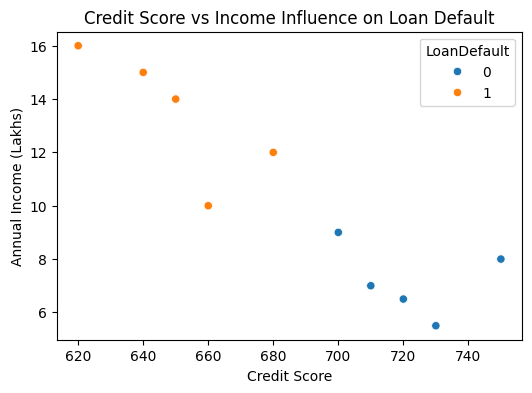

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt
# Step 2: Compare average credit score and income
print("Average Credit Score by Default:")
print(df.groupby("LoanDefault")["CreditScore"].mean())

print("\nAverage Income by Default:")
print(df.groupby("LoanDefault")["AnnualIncome"].mean())

# Step 3: Correlation Analysis
correlation = df[["CreditScore","AnnualIncome","LoanDefault"]].corr()
print("\nCorrelation Matrix")
print(correlation)

# Step 4: Visualization
plt.figure(figsize=(6,4))
sns.scatterplot(x="CreditScore", y="AnnualIncome", hue="LoanDefault", data=df)

plt.title("Credit Score vs Income Influence on Loan Default")
plt.xlabel("Credit Score")
plt.ylabel("Annual Income (Lakhs)")

plt.show()

## Interpretation 4: Suggest banking policies based on model output.

In [19]:
df["LoanIncomeRatio"] = df["LoanAmount"] / df["AnnualIncome"]
def banking_policy(row):

    if row["CreditScore"] < 650:
        return "Reject Loan (Very High Risk)"

    elif row["LoanIncomeRatio"] > 0.8:
        return "Reduce Loan Amount or Request Collateral"

    elif row["EmploymentType"] == "Self-Employed":
        return "Require Additional Income Verification"

    else:
        return "Loan Approved"

df["BankDecision"] = df.apply(banking_policy, axis=1)

df[["CreditScore","AnnualIncome","LoanAmount","LoanIncomeRatio","EmploymentType","BankDecision"]]

,CreditScore,AnnualIncome,LoanAmount,LoanIncomeRatio,EmploymentType,BankDecision
0,720,6.5,5,0.769231,0,Loan Approved
1,680,12.0,10,0.833333,1,Reduce Loan Amount or Request Collateral
2,750,8.0,6,0.750000,0,Loan Approved
3,640,15.0,12,0.800000,1,Reject Loan (Very High Risk)
4,710,7.0,5,0.714286,0,Loan Approved
5,660,10.0,9,0.900000,0,Reduce Loan Amount or Request Collateral
6,730,5.5,4,0.727273,0,Loan Approved
7,650,14.0,11,0.785714,1,Loan Approved
8,700,9.0,7,0.777778,0,Loan Approved
9,620,16.0,13,0.812500,1,Reject Loan (Very High Risk)


## Interpretation 5: Compare KNN with Decision Trees for this problem.

In [26]:
le = LabelEncoder()
df["EmploymentType"] = le.fit_transform(df["EmploymentType"])

X = df.drop("LoanDefault", axis=1)
y = df["LoanDefault"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)

knn_pred = knn.predict(X_test)

dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

knn_accuracy = accuracy_score(y_test, knn_pred)
dt_accuracy = accuracy_score(y_test, dt_pred)

print("KNN Accuracy:", knn_accuracy)
print("Decision Tree Accuracy:", dt_accuracy)

KNN Accuracy: 1.0
Decision Tree Accuracy: 1.0


## Interpretation 6: What happens if LoanAmount dominates distance calculation?

If LoanAmount dominates distance calculation, KNN will classify customers mainly based on loan size, ignoring other factors like:

credit score

income

employment stability

In [42]:
# Select two customers from dataset
customer_A = df.iloc[0]
customer_B = df.iloc[3]

# Calculate distance between two customers
distance = np.sqrt(
    (customer_A["Age"] - customer_B["Age"])**2 +
    (customer_A["AnnualIncome"] - customer_B["AnnualIncome"])**2 +
    (customer_A["CreditScore"] - customer_B["CreditScore"])**2 +
    (customer_A["LoanAmount"] - customer_B["LoanAmount"])**2 +
    (customer_A["LoanTerm"] - customer_B["LoanTerm"])**2
)

print("Distance between two customers:", distance)

Distance between two customers: 84.2926449934987


## Interpretation 7: Should KNN be used in real-time loan approval systems?

KNN does not build a mathematical model.

Instead, it compares the new customer with all existing customers.

KNN can still be useful for:

small datasets

prototype models

similarity-based customer analysis.

But not ideal for large real-time systems.